# Linear Regression Analysis Report

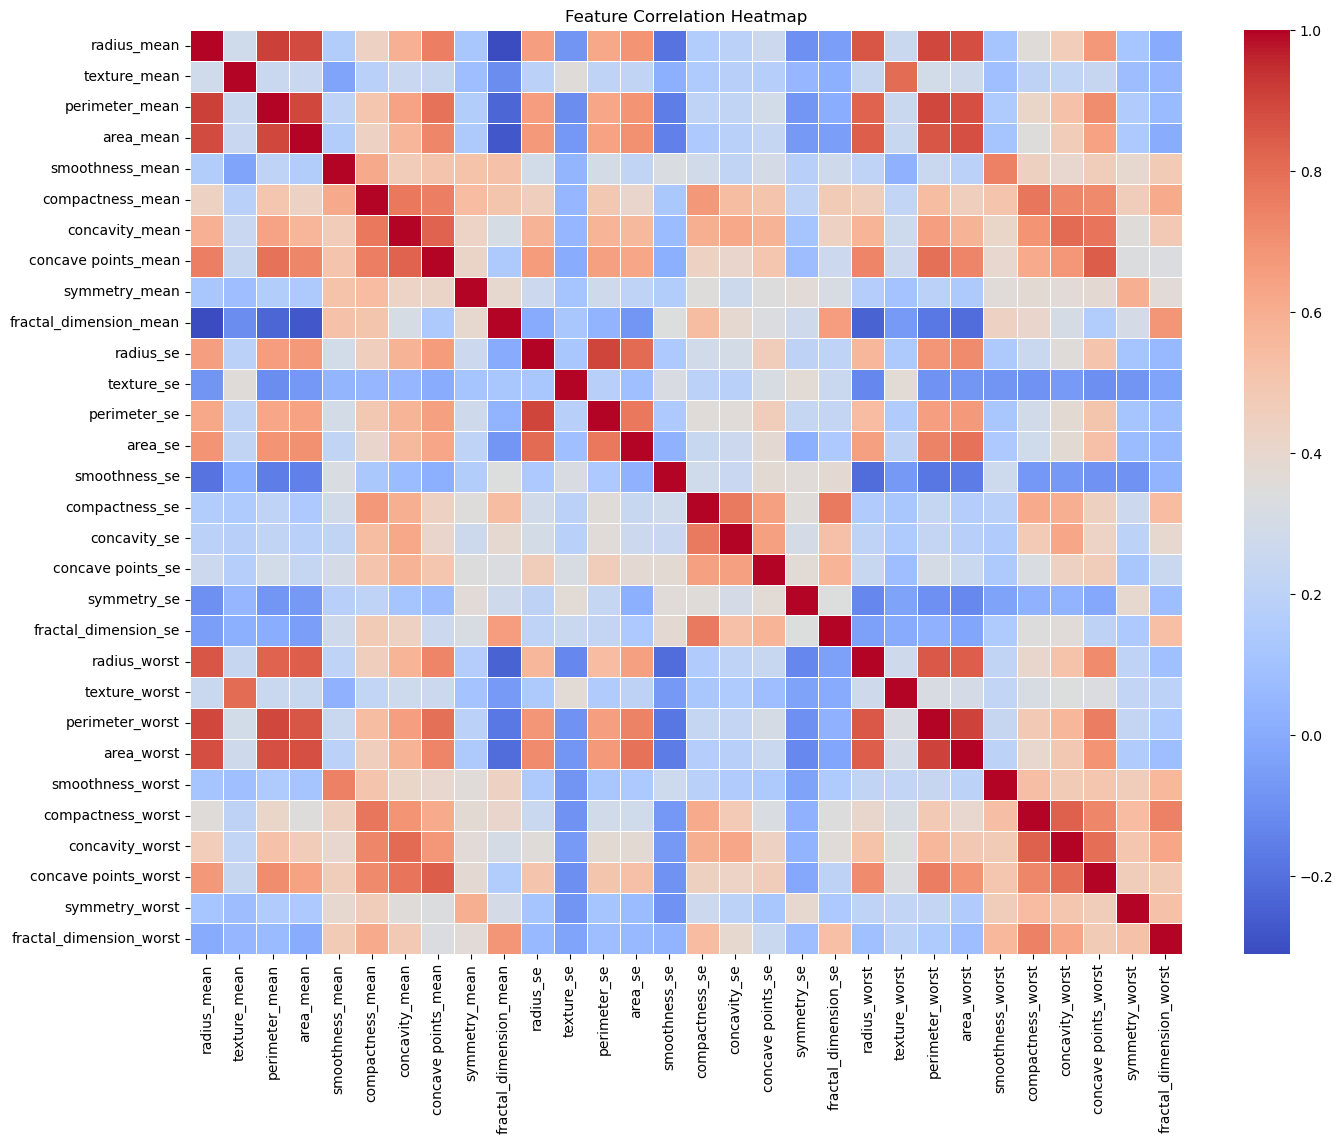

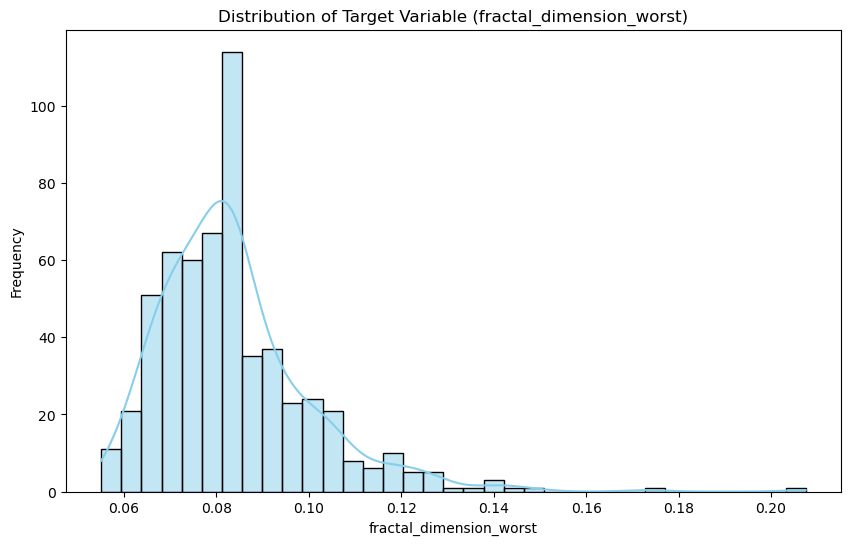

--- Model Performance Metrics ---
Mean Squared Error (MSE): 0.0000602
Mean Absolute Error (MAE): 0.00467
Root Mean Squared Error (RMSE): 0.00776
R² Score: 0.821


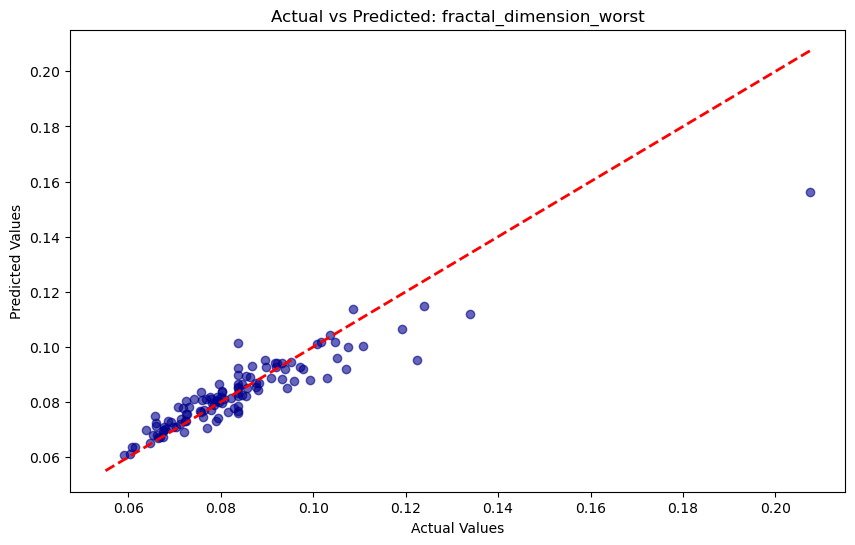

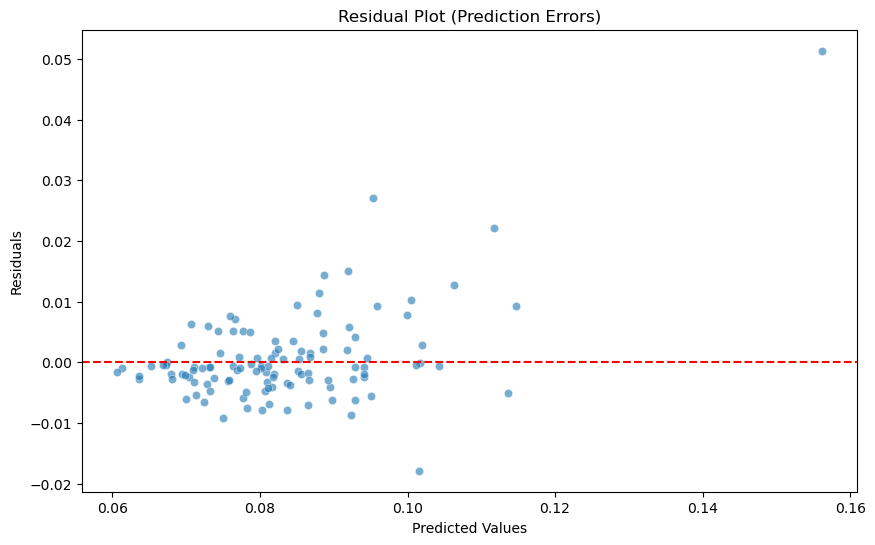

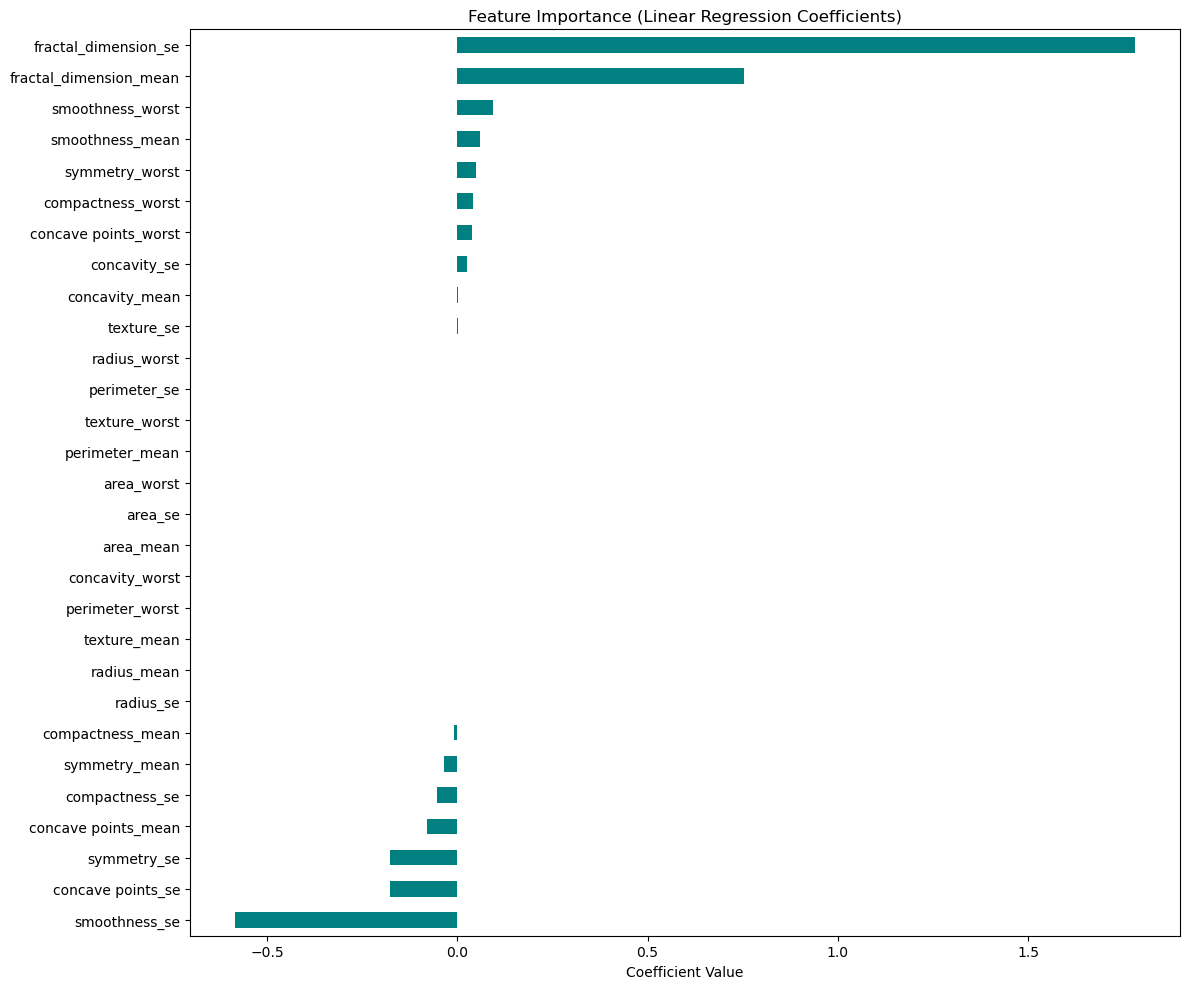

       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   530.000000    511.000000      512.000000   507.000000   
mean     14.125274     19.314227       92.530273   660.026430   
std       3.511943      4.227823       24.448352   350.000703   
min       6.981000      9.710000       47.920000   143.500000   
25%      11.717500     16.175000       75.532500   427.950000   
50%      13.390000     18.840000       87.090000   561.000000   
75%      15.750000     21.805000      103.925000   790.850000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       514.000000        508.000000      517.000000           511.000000   
mean          0.096575          0.105014        0.088315             0.049675   
std           0.014106          0.053031        0.079049             0.039314   
min           0.052630          0.019380        0.000000             0.000000   
25%      

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load the Dataset
# Ensure 'data_for regression.csv' is in your working directory
df = pd.read_csv('data_for regression.csv')

# 2. Data Cleaning: Handling Missing Values
# Replacing missing values with the mean of each column 
df_cleaned = df.fillna(df.mean())

# 3. Exploratory Data Analysis (EDA) & Visualizations
# A. Correlation Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(df_cleaned.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

# B. Target Variable Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['fractal_dimension_worst'], kde=True, color='skyblue')
plt.title('Distribution of Target Variable (fractal_dimension_worst)')
plt.xlabel('fractal_dimension_worst')
plt.ylabel('Frequency')
plt.savefig('target_distribution.png')
plt.show()

# 4. Feature Selection & Data Splitting
# Dependent variable (y) is the last column 
X = df_cleaned.drop(columns=['fractal_dimension_worst'])
y = df_cleaned['fractal_dimension_worst']

# Splitting into 80% training and 20% testing 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Regression Model
# Applying Linear Regression 
model = LinearRegression()
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# 6. Model Performance (Error Analysis)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.7f}")
print(f"Mean Absolute Error (MAE): {mae:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
print(f"R² Score: {r2:.3f}")

# 7. Predictive Analysis Visualizations
# A. Actual vs Predicted Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted: fractal_dimension_worst')
plt.savefig('actual_vs_predicted.png')
plt.show()

# B. Residual Plot (Error Distribution)
plt.figure(figsize=(10, 6))
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot (Prediction Errors)')
plt.savefig('residual_plot.png')
plt.show()

# C. Feature Importance (Coefficients)
plt.figure(figsize=(12, 10))
feature_importance = pd.Series(model.coef_, index=X.columns).sort_values(ascending=True)
feature_importance.plot(kind='barh', color='teal')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print(df.describe())
print(df.head(20))

In [14]:
# Check null values
print(df.isnull().sum())


radius_mean                39
texture_mean               58
perimeter_mean             57
area_mean                  62
smoothness_mean            55
compactness_mean           61
concavity_mean             52
concave points_mean        58
symmetry_mean              60
fractal_dimension_mean     54
radius_se                  64
texture_se                 52
perimeter_se               47
area_se                    61
smoothness_se              42
compactness_se             54
concavity_se               49
concave points_se          64
symmetry_se                61
fractal_dimension_se       41
radius_worst               62
texture_worst              63
perimeter_worst            52
area_worst                 56
smoothness_worst           36
compactness_worst          53
concavity_worst            52
concave points_worst       51
symmetry_worst             55
fractal_dimension_worst    57
dtype: int64


In [15]:
#Fill null values with mean
df = df.fillna(df.mean())

# Verify again
print(df.isnull().sum())
print(df.head(5))

radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122

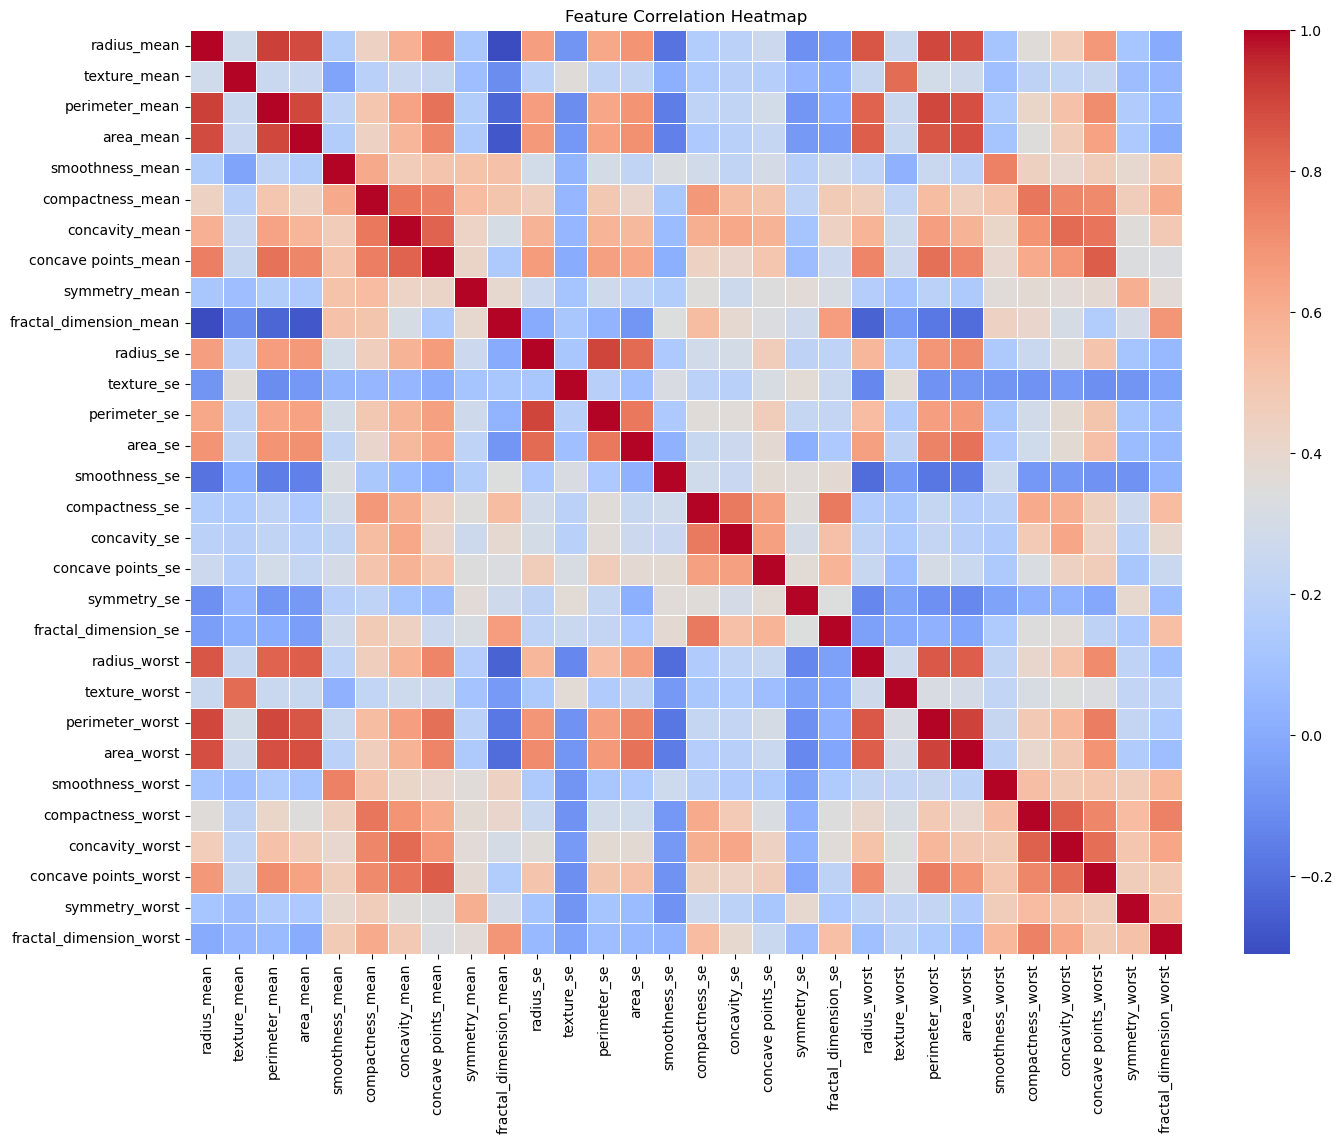

In [16]:
# 3. Exploratory Data Analysis (EDA) & Visualizations
# A. Correlation Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(df_cleaned.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

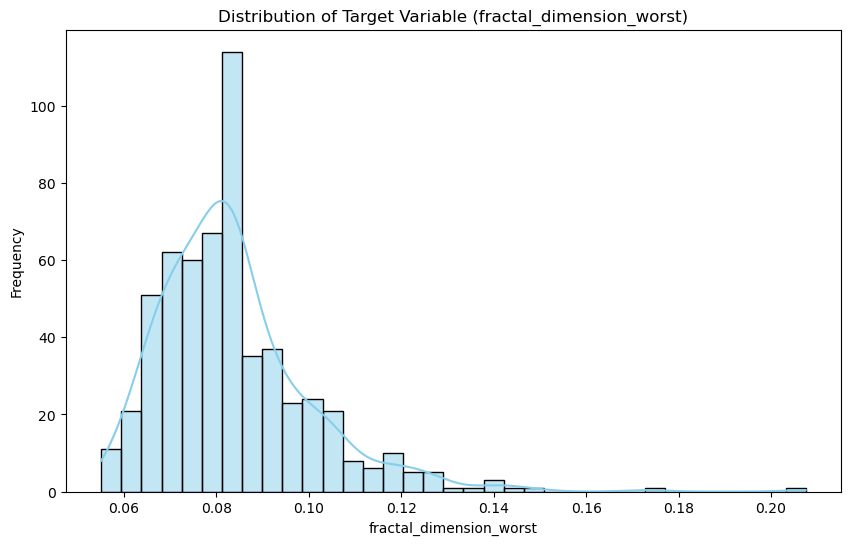

In [17]:
# B. Target Variable Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['fractal_dimension_worst'], kde=True, color='skyblue')
plt.title('Distribution of Target Variable (fractal_dimension_worst)')
plt.xlabel('fractal_dimension_worst')
plt.ylabel('Frequency')
plt.savefig('target_distribution.png')
plt.show()

In [20]:
# 4. Feature Selection & Data Splitting
# Dependent variable (y) is the last column 
X = df_cleaned.drop(columns=['fractal_dimension_worst'])
y = df_cleaned['fractal_dimension_worst']

# Splitting into 80% training and 20% testing 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 5. Regression Model
# Applying Linear Regression 
model = LinearRegression()
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# 6. Model Performance (Error Analysis)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.7f}")
print(f"Mean Absolute Error (MAE): {mae:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
print(f"R² Score: {r2:.3f}")

--- Model Performance Metrics ---
Mean Squared Error (MSE): 0.0000602
Mean Absolute Error (MAE): 0.00467
Root Mean Squared Error (RMSE): 0.00776
R² Score: 0.821


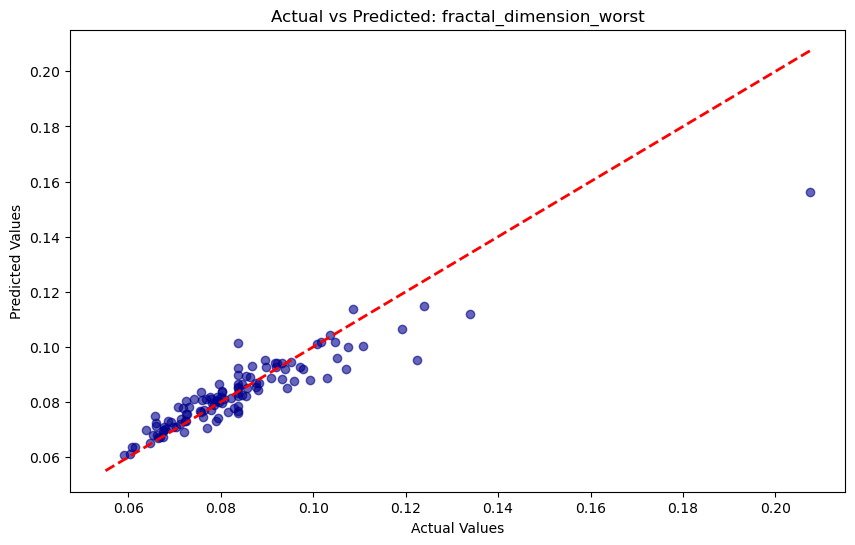

In [22]:
# 7. Predictive Analysis Visualizations
# A. Actual vs Predicted Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted: fractal_dimension_worst')
plt.savefig('actual_vs_predicted.png')
plt.show()

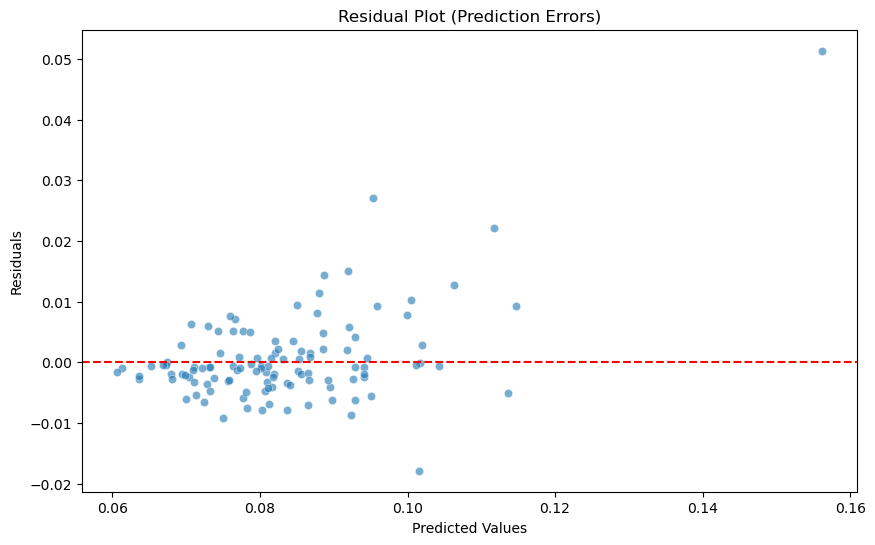

In [23]:
# B. Residual Plot (Error Distribution)
plt.figure(figsize=(10, 6))
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot (Prediction Errors)')
plt.savefig('residual_plot.png')
plt.show()

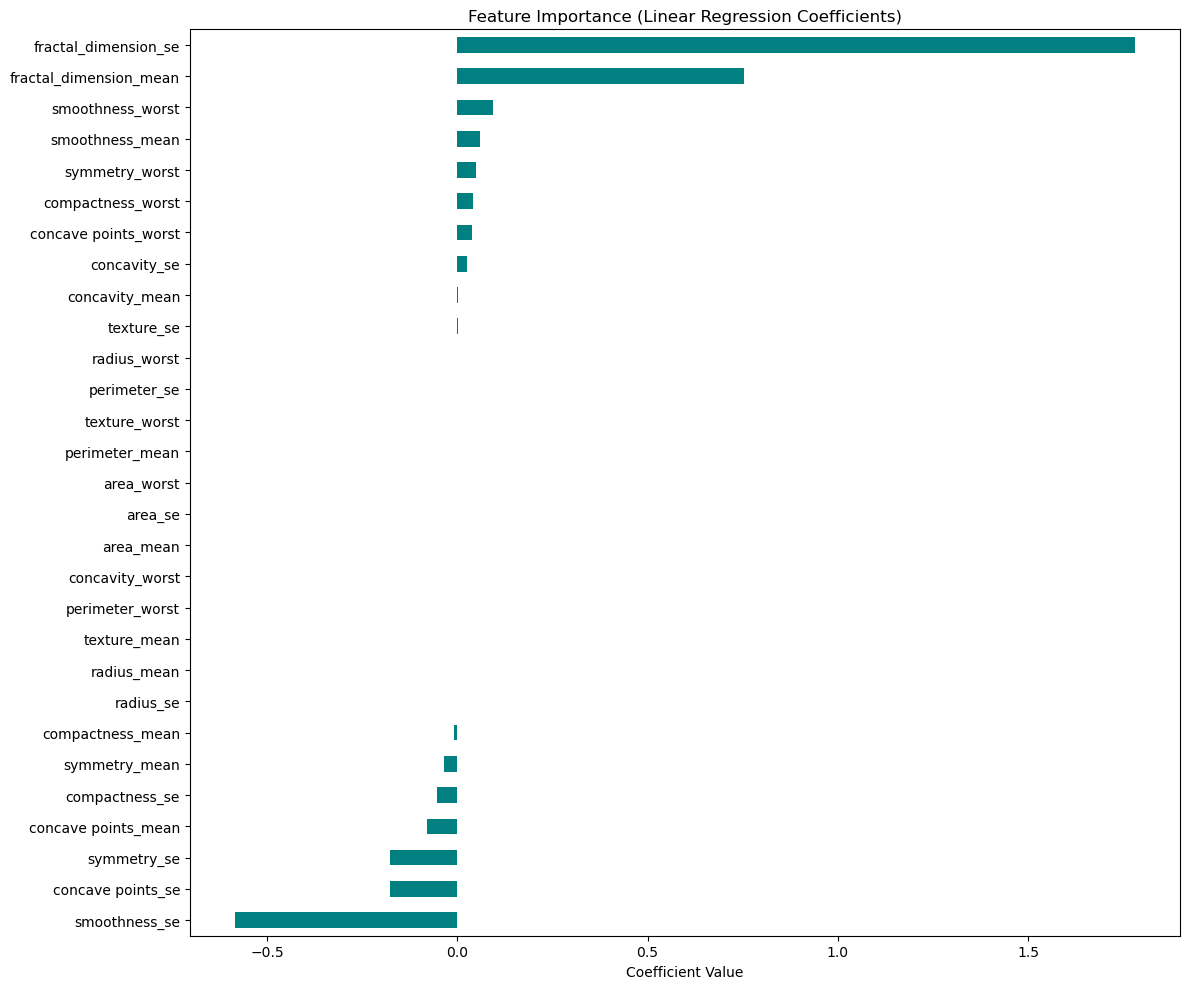

       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.125274     19.314227       92.530273   660.026430   
std       3.389231      4.006155       23.189206   330.346726   
min       6.981000      9.710000       47.920000   143.500000   
25%      11.840000     16.540000       76.830000   442.700000   
50%      13.640000     19.314227       88.680000   588.900000   
75%      15.460000     21.530000      102.100000   731.300000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096575          0.105014        0.088315             0.049675   
std           0.013405          0.050103        0.075344             0.037253   
min           0.052630          0.019380        0.000000             0.000000   
25%      

In [24]:
# C. Feature Importance (Coefficients)
plt.figure(figsize=(12, 10))
feature_importance = pd.Series(model.coef_, index=X.columns).sort_values(ascending=True)
feature_importance.plot(kind='barh', color='teal')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print(df.describe())
print(df.head(20))